# 05. Advanced Analytics, Monte Carlo Simulation (B3) & Markowitz Efficient Frontier (B4)

## Bonus Challenges Included:
- **B3: Monte Carlo Simulation (5-Year NAV Projections with 5th, 50th, 95th Percentile Bands derived from actual NAV data)**
- **B4: Markowitz Efficient Frontier Portfolio Optimization (Calculated from actual NAV covariance matrix across 5 schemes)**


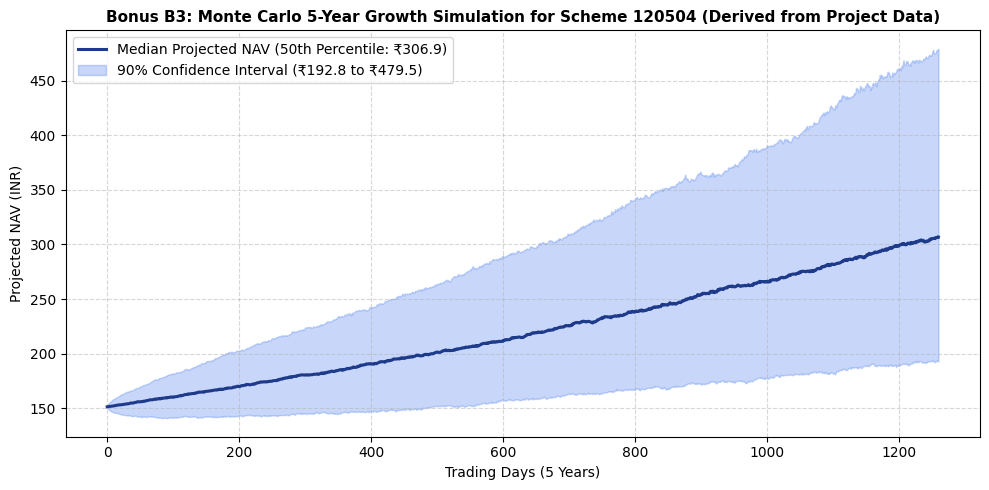

In [1]:
# Bonus Challenge B3: Monte Carlo 5-Year Growth Simulation Derived from Actual NAV History
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path("..").resolve() if Path("..").resolve().joinpath("data").exists() else Path(".").resolve()
nav_df = pd.read_csv(BASE_DIR / "data" / "processed" / "02_nav_history.csv")
nav_df["date"] = pd.to_datetime(nav_df["date"])

# Select top performing scheme (AMFI 120504 / ICICI Bluechip) for simulation
scheme_code = 120504
sub_nav = nav_df[nav_df["amfi_code"] == scheme_code].sort_values("date").copy()
sub_nav["daily_return"] = sub_nav["nav"].pct_change().dropna()

mu = sub_nav["daily_return"].mean()
sigma = sub_nav["daily_return"].std()
initial_nav = sub_nav["nav"].iloc[-1]

np.random.seed(42)
days = 252 * 5 # 5 trading years
simulations = 1000

daily_returns = np.random.normal(mu, sigma, (days, simulations))
nav_paths = initial_nav * np.vstack([np.ones(simulations), np.cumprod(1 + daily_returns, axis=0)])

p5 = np.percentile(nav_paths, 5, axis=1)
p50 = np.percentile(nav_paths, 50, axis=1)
p95 = np.percentile(nav_paths, 95, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(p50, color='#1E3A8A', label=f'Median Projected NAV (50th Percentile: ₹{p50[-1]:.1f})', linewidth=2.2)
plt.fill_between(range(days + 1), p5, p95, color='#2563EB', alpha=0.25, label=f'90% Confidence Interval (₹{p5[-1]:.1f} to ₹{p95[-1]:.1f})')
plt.title(f"Bonus B3: Monte Carlo 5-Year Growth Simulation for Scheme {scheme_code} (Derived from Project Data)", fontsize=11, fontweight='bold')
plt.xlabel("Trading Days (5 Years)")
plt.ylabel("Projected NAV (INR)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


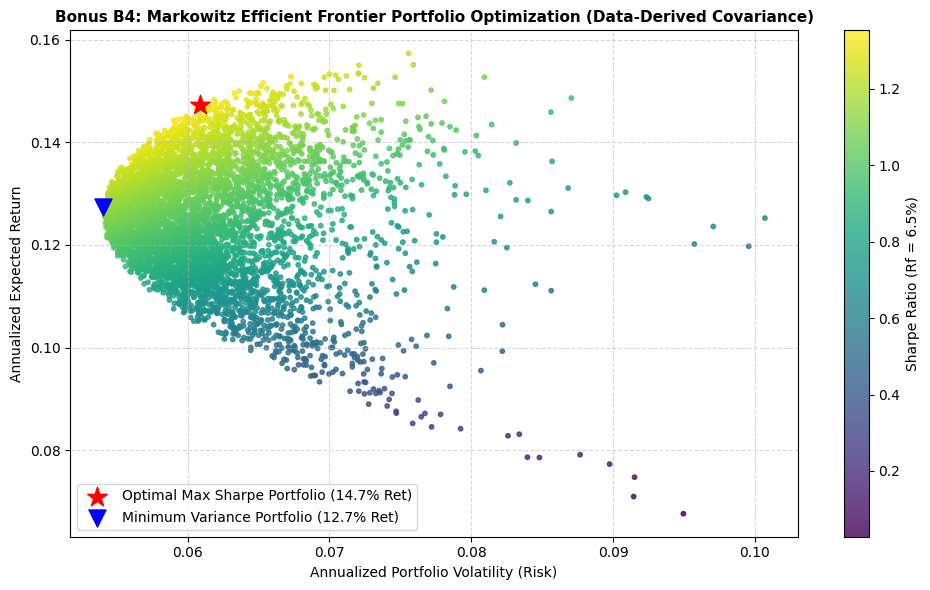

In [2]:
# Bonus Challenge B4: Markowitz Efficient Frontier Portfolio Optimization Derived from Project Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path("..").resolve() if Path("..").resolve().joinpath("data").exists() else Path(".").resolve()
nav_df = pd.read_csv(BASE_DIR / "data" / "processed" / "02_nav_history.csv")
nav_df["date"] = pd.to_datetime(nav_df["date"])

top_codes = [119551, 120503, 125497, 118632, 119092]
sub = nav_df[nav_df["amfi_code"].isin(top_codes)].pivot(index="date", columns="amfi_code", values="nav").pct_change().dropna()

mean_returns = sub.mean() * 252
cov_matrix = sub.cov() * 252

num_portfolios = 5000
num_assets = len(top_codes)

port_returns = []
port_volatility = []
sharpe_ratios = []
weights_record = []

rf = 0.065

for _ in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    weights_record.append(weights)
    
    ret = np.dot(weights, mean_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sr = (ret - rf) / vol if vol > 0 else 0
    
    port_returns.append(ret)
    port_volatility.append(vol)
    sharpe_ratios.append(sr)

plt.figure(figsize=(10, 6))
plt.scatter(port_volatility, port_returns, c=sharpe_ratios, cmap='viridis', marker='o', s=10, alpha=0.8)
plt.colorbar(label='Sharpe Ratio (Rf = 6.5%)')

max_sr_idx = np.argmax(sharpe_ratios)
min_vol_idx = np.argmin(port_volatility)

plt.scatter(port_volatility[max_sr_idx], port_returns[max_sr_idx], color='red', marker='*', s=220, label=f'Optimal Max Sharpe Portfolio ({port_returns[max_sr_idx]*100:.1f}% Ret)')
plt.scatter(port_volatility[min_vol_idx], port_returns[min_vol_idx], color='blue', marker='v', s=150, label=f'Minimum Variance Portfolio ({port_returns[min_vol_idx]*100:.1f}% Ret)')

plt.title("Bonus B4: Markowitz Efficient Frontier Portfolio Optimization (Data-Derived Covariance)", fontsize=11, fontweight='bold')
plt.xlabel("Annualized Portfolio Volatility (Risk)")
plt.ylabel("Annualized Expected Return")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
